# Fase 2 — Análise Exploratória

**Objetivo:** entender o problema de roteamento antes de treinar qualquer classificador.

Modelo pequeno: `gpt-3.5-turbo-1106` | Modelo grande: `gpt-4-1106-preview`

Dataset: `dados/processado/routerbench_fase1.csv` (34.771 perguntas, gerado na Fase 1).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../dados/processado/routerbench_fase1.csv')
df['tamanho_pergunta'] = df['pergunta'].str.len()  # numero de caracteres

print(f'{len(df)} perguntas carregadas')
df.head(3)

34771 perguntas carregadas


,pergunta,categoria,acerto_pequeno,acerto_grande,custo_pequeno,custo_grande,tamanho_pergunta
0,An astronomer observes that a planet rotates f...,arc-challenge,1,1,0.000093,0.00092,383
1,A group of engineers wanted to know how differ...,arc-challenge,1,1,0.000106,0.00107,506
2,"According to cell classification, prokaryotic ...",arc-challenge,1,1,0.000089,0.00091,337


## 1-3. Sobreposição de acertos entre os dois modelos

Cruzamos o acerto do pequeno com o acerto do grande em 4 grupos:
- **Ambos acertaram** → o modelo grande foi desperdício de dinheiro nessa pergunta
- **Só o grande acertou** → aqui o roteamento tem valor real (vale pagar mais)
- **Só o pequeno acertou** → o grande "errou à toa"; caso raro, mas existe
- **Ambos erraram** → nenhum roteador resolve, o problema é da pergunta, não do roteamento

                      contagem  percentual (%)
grupo                                         
Ambos acertaram          21838            62.8
Só o grande acertou       7917            22.8
Ambos erraram             3460            10.0
Só o pequeno acertou      1556             4.5


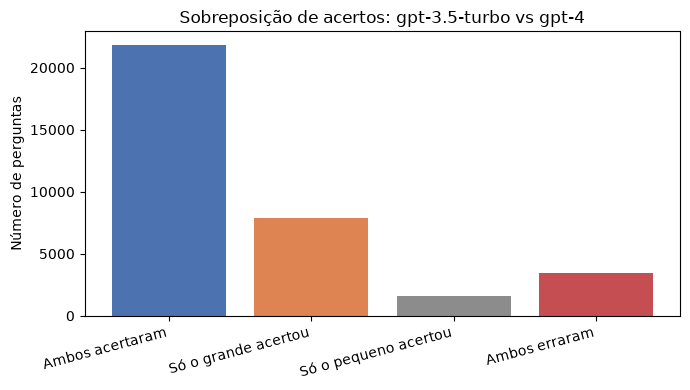

In [2]:
def classificar(row):
    if row['acerto_pequeno'] == 1 and row['acerto_grande'] == 1:
        return 'Ambos acertaram'
    if row['acerto_pequeno'] == 0 and row['acerto_grande'] == 1:
        return 'Só o grande acertou'
    if row['acerto_pequeno'] == 1 and row['acerto_grande'] == 0:
        return 'Só o pequeno acertou'
    return 'Ambos erraram'

df['grupo'] = df.apply(classificar, axis=1)
contagem = df['grupo'].value_counts()
percentual = (contagem / len(df) * 100).round(1)

resumo = pd.DataFrame({'contagem': contagem, 'percentual (%)': percentual})
print(resumo)

ordem = ['Ambos acertaram', 'Só o grande acertou', 'Só o pequeno acertou', 'Ambos erraram']
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(ordem, contagem.reindex(ordem), color=['#4C72B0', '#DD8452', '#8C8C8C', '#C44E52'])
ax.set_ylabel('Número de perguntas')
ax.set_title('Sobreposição de acertos: gpt-3.5-turbo vs gpt-4')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../resultados/sobreposicao_acertos.png', dpi=120)
plt.show()

## 4. Tamanho da pergunta vs erro do modelo pequeno

Hipótese: perguntas mais longas (mais contexto, mais chance de detalhe complicado) são mais difíceis para o modelo pequeno.

Usamos o teste de **Mann-Whitney U** em vez do teste-t porque não queremos assumir que o tamanho da pergunta segue distribuição normal (números de caracteres tendem a ter cauda longa à direita — a maioria das perguntas é curta, mas algumas são bem longas).

Tamanho médio quando o pequeno ACERTA: 760 caracteres (mediana 710)
Tamanho médio quando o pequeno ERRA:   771 caracteres (mediana 711)

Mann-Whitney U: estatística=131147900, p-valor=2.81e-02


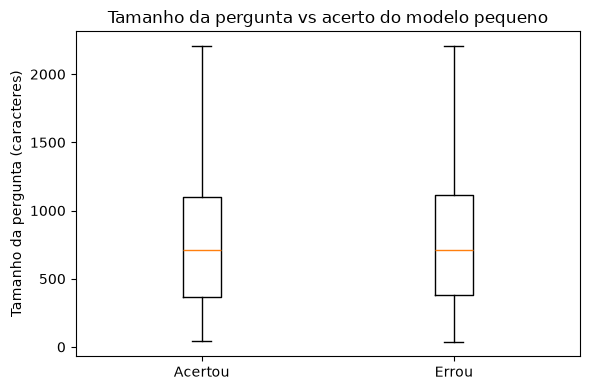

In [3]:
from scipy import stats

acertou = df[df['acerto_pequeno'] == 1]['tamanho_pergunta']
errou = df[df['acerto_pequeno'] == 0]['tamanho_pergunta']

print(f'Tamanho médio quando o pequeno ACERTA: {acertou.mean():.0f} caracteres (mediana {acertou.median():.0f})')
print(f'Tamanho médio quando o pequeno ERRA:   {errou.mean():.0f} caracteres (mediana {errou.median():.0f})')

estatistica, p_valor = stats.mannwhitneyu(acertou, errou)
print(f'\nMann-Whitney U: estatística={estatistica:.0f}, p-valor={p_valor:.2e}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([acertou, errou], tick_labels=['Acertou', 'Errou'], showfliers=False)
ax.set_ylabel('Tamanho da pergunta (caracteres)')
ax.set_title('Tamanho da pergunta vs acerto do modelo pequeno')
plt.tight_layout()
plt.savefig('../resultados/tamanho_vs_acerto.png', dpi=120)
plt.show()

## 5. Diferença por categoria de tarefa

`gsm8k` (matemática de ensino fundamental) e `mbpp` (geração de código) exigem raciocínio passo-a-passo e resposta exata — esperamos que sejam mais difíceis para o modelo pequeno do que tarefas de conhecimento factual/senso comum (`mmlu`, `hellaswag`, `arc-challenge`, `winogrande`), que geralmente são múltipla escolha.

               n_perguntas  acerto_pequeno  acerto_grande
categoria                                                
winogrande            1267           0.579          0.819
hellaswag            10042           0.587          0.840
mmlu                 14037           0.647          0.812
mbpp                   425           0.652          0.687
mtbench                 80           0.688          0.812
gsm8k                 7450           0.823          0.956
arc-challenge         1470           0.831          0.962


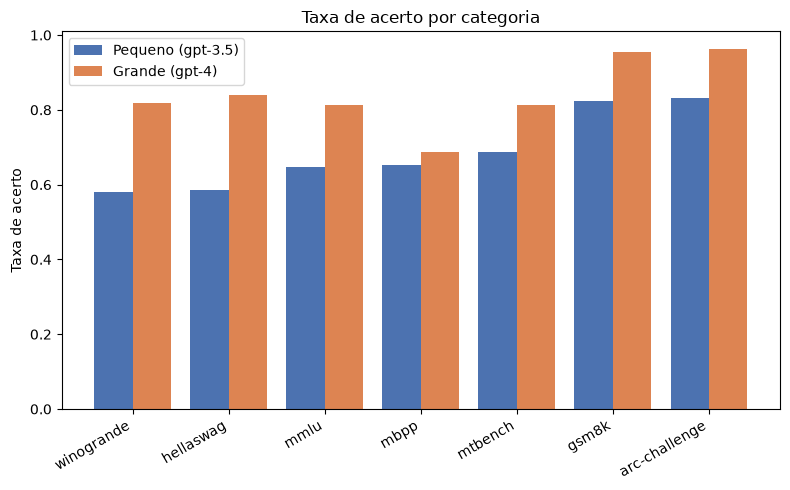

In [4]:
por_categoria = df.groupby('categoria').agg(
    n_perguntas=('acerto_pequeno', 'size'),
    acerto_pequeno=('acerto_pequeno', 'mean'),
    acerto_grande=('acerto_grande', 'mean'),
).sort_values('acerto_pequeno')

print(por_categoria.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(por_categoria))
ax.bar([i - 0.2 for i in x], por_categoria['acerto_pequeno'], width=0.4, label='Pequeno (gpt-3.5)', color='#4C72B0')
ax.bar([i + 0.2 for i in x], por_categoria['acerto_grande'], width=0.4, label='Grande (gpt-4)', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(por_categoria.index, rotation=30, ha='right')
ax.set_ylabel('Taxa de acerto')
ax.set_title('Taxa de acerto por categoria')
ax.legend()
plt.tight_layout()
plt.savefig('../resultados/acerto_por_categoria.png', dpi=120)
plt.show()

## 6. Roteador oráculo — o teto teórico de economia

O oráculo "sabe" antecipadamente se cada modelo vai acertar. Regra: usa o pequeno sempre que ele acerta; só usa o grande quando o pequeno erra e o grande acerta; se os dois erram, usa o pequeno (mais barato, já que vai errar de qualquer forma).

Isso dá a **acurácia máxima possível** roteando entre só esses dois modelos, ao **menor custo possível** para atingi-la. Se esse teto não for muito melhor que só usar o modelo grande, o projeto inteiro não vale a pena — por isso calculamos isso agora, antes de treinar qualquer classificador.

In [5]:
df['rota_oraculo'] = df.apply(lambda r: 'grande' if (r['acerto_pequeno'] == 0 and r['acerto_grande'] == 1) else 'pequeno', axis=1)
df['acerto_oraculo'] = df.apply(lambda r: r['acerto_grande'] if r['rota_oraculo'] == 'grande' else r['acerto_pequeno'], axis=1)
df['custo_oraculo'] = df.apply(lambda r: r['custo_grande'] if r['rota_oraculo'] == 'grande' else r['custo_pequeno'], axis=1)

politicas = pd.DataFrame({
    'acuracia': [df['acerto_pequeno'].mean(), df['acerto_grande'].mean(), df['acerto_oraculo'].mean()],
    'custo_total_usd': [df['custo_pequeno'].sum(), df['custo_grande'].sum(), df['custo_oraculo'].sum()],
    '%_enviado_ao_grande': [0.0, 100.0, (df['rota_oraculo'] == 'grande').mean() * 100],
}, index=['Tudo pequeno', 'Tudo grande', 'Oráculo (teto)'])

politicas['economia_vs_tudo_grande (%)'] = (1 - politicas['custo_total_usd'] / politicas.loc['Tudo grande', 'custo_total_usd']) * 100
print(politicas.round(3))

                acuracia  custo_total_usd  %_enviado_ao_grande  \
Tudo pequeno       0.673            8.476                0.000   
Tudo grande        0.856          113.318              100.000   
Oráculo (teto)     0.900           30.327               22.769   

                economia_vs_tudo_grande (%)  
Tudo pequeno                         92.520  
Tudo grande                           0.000  
Oráculo (teto)                       73.237  


## Hipóteses sobre o que torna uma pergunta "difícil"

(Baseadas nos resultados acima — viram features candidatas para a Fase 3)

1. **Categoria de tarefa é o sinal mais forte que encontramos.** A taxa de acerto do modelo pequeno varia de 57,9% (winogrande) a 83,1% (arc-challenge) — uma diferença de 25 pontos percentuais só pela categoria. `categoria` deve ser feature na Fase 3.
2. **Tamanho da pergunta, sozinho, é um sinal fraco.** A diferença de mediana entre acerto (710 caracteres) e erro (711 caracteres) é praticamente nula. O teste de Mann-Whitney deu p=0,028 (estatisticamente "significativo" a 5%), mas isso é esperado com quase 35 mil linhas — até efeitos minúsculos ficam "significativos". Não vamos confundir significância estatística com relevância prática aqui.
3. **A intuição de que "matemática é mais difícil" não se confirmou** — pelo contrário, gsm8k teve a segunda maior taxa de acerto (82,3%/95,6%). As perguntas de senso comum (winogrande, hellaswag) foram relativamente mais difíceis para os dois modelos.
4. **Hipóteses ainda não testadas, para investigar com features na Fase 3:** presença de números/fórmulas no texto, formato da pergunta (múltipla escolha A/B/C/D vs. resposta livre), e complexidade lexical.

## Conclusão (escrita pela estudante)

*(espaço reservado — a conclusão da Fase 2 vai aqui, escrita por mim com apoio do Claude na revisão)*